In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11, 'axes.labelsize': 10})

PATH = r'D:\Laravel\Flask-MachineLearning\Data.csv'
df = pd.read_csv(PATH)

DROP_COLS = ['id', 'high_risk_flag', 'focus_score', 'productivity_score']
df = df.drop(columns=DROP_COLS)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Kolom yang dihapus di awal: {DROP_COLS}')

Loaded: 3,500 rows x 20 columns
Kolom yang dihapus di awal: ['id', 'high_risk_flag', 'focus_score', 'productivity_score']


In [3]:
df.head()

,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,device_type,digital_dependence_score
0,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,Android,25.700000
1,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,Laptop,30.100000
2,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,Android,40.600000
3,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,Tablet,36.684152
4,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,Android,48.400000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3500 non-null   int64  
 1   gender                    3500 non-null   object 
 2   region                    3500 non-null   object 
 3   income_level              3500 non-null   object 
 4   education_level           3500 non-null   object 
 5   daily_role                3500 non-null   object 
 6   device_hours_per_day      3500 non-null   float64
 7   phone_unlocks             3500 non-null   int64  
 8   notifications_per_day     3500 non-null   int64  
 9   social_media_mins         3500 non-null   int64  
 10  study_mins                3500 non-null   int64  
 11  physical_activity_days    3500 non-null   float64
 12  sleep_hours               3500 non-null   float64
 13  sleep_quality             3500 non-null   float64
 14  anxiety_

In [5]:
missing = df.isnull().sum()
dupes = df.duplicated().sum()
print(f'Missing values : {missing.sum()}')
print(f'Duplicate rows : {dupes}')
print(f'\nValue counts per column:')
for col in df.select_dtypes(include='object').columns:
    print(f'  {col}: {df[col].nunique()} unique -> {df[col].unique().tolist()}')

Missing values : 0
Duplicate rows : 0

Value counts per column:
  gender: 2 unique -> ['Female', 'Male']
  region: 6 unique -> ['Asia', 'Africa', 'North America', 'Middle East', 'Europe', 'South America']
  income_level: 4 unique -> ['High', 'Lower-Mid', 'Low', 'Upper-Mid']
  education_level: 4 unique -> ['High School', 'Master', 'Bachelor', 'PhD']
  daily_role: 5 unique -> ['Part-time/Shift', 'Full-time Employee', 'Caregiver/Home', 'Unemployed_Looking', 'Student']
  device_type: 4 unique -> ['Android', 'Laptop', 'Tablet', 'iPhone']


In [6]:
df.describe().round(2)

,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,digital_dependence_score
count,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00
mean,28.08,7.32,147.11,335.12,159.36,108.12,3.35,7.25,2.71,7.18,8.83,5.08,6.42,36.68
std,9.35,3.24,67.77,239.68,132.75,79.80,1.88,1.29,1.10,5.04,5.74,3.40,3.02,14.12
min,13.00,0.28,9.00,22.00,0.00,0.00,0.00,3.00,1.00,0.00,0.00,1.00,0.00,5.60
25%,21.00,4.87,96.00,170.00,68.00,42.00,2.00,6.41,1.92,4.00,4.00,1.34,4.00,26.20
50%,27.00,6.76,136.00,268.00,119.00,102.00,3.00,7.29,2.91,6.00,8.00,4.81,7.50,35.30
75%,34.00,9.15,187.00,434.00,204.00,163.00,5.00,8.16,3.28,8.85,13.00,8.79,8.90,45.10
max,50.00,17.16,374.00,1211.00,631.00,418.00,7.00,11.00,5.00,27.15,27.00,10.00,10.00,89.20


In [7]:
TARGET = 'digital_dependence_score'
num_cols = df.select_dtypes(include=np.number).columns

skew_df = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(3),
    'Status': df[num_cols].skew().apply(
        lambda x: 'Normal' if abs(x)<0.5 else 'Moderate' if abs(x)<1 else 'Skewed')
})
skew_df.sort_values('Skewness', ascending=False)

,Skewness,Status
notifications_per_day,1.634,Skewed
social_media_mins,1.605,Skewed
anxiety_score,1.557,Skewed
device_hours_per_day,0.716,Moderate
phone_unlocks,0.660,Moderate
digital_dependence_score,0.640,Moderate
study_mins,0.493,Normal
age,0.478,Normal
depression_score,0.478,Normal
stress_level,0.215,Normal


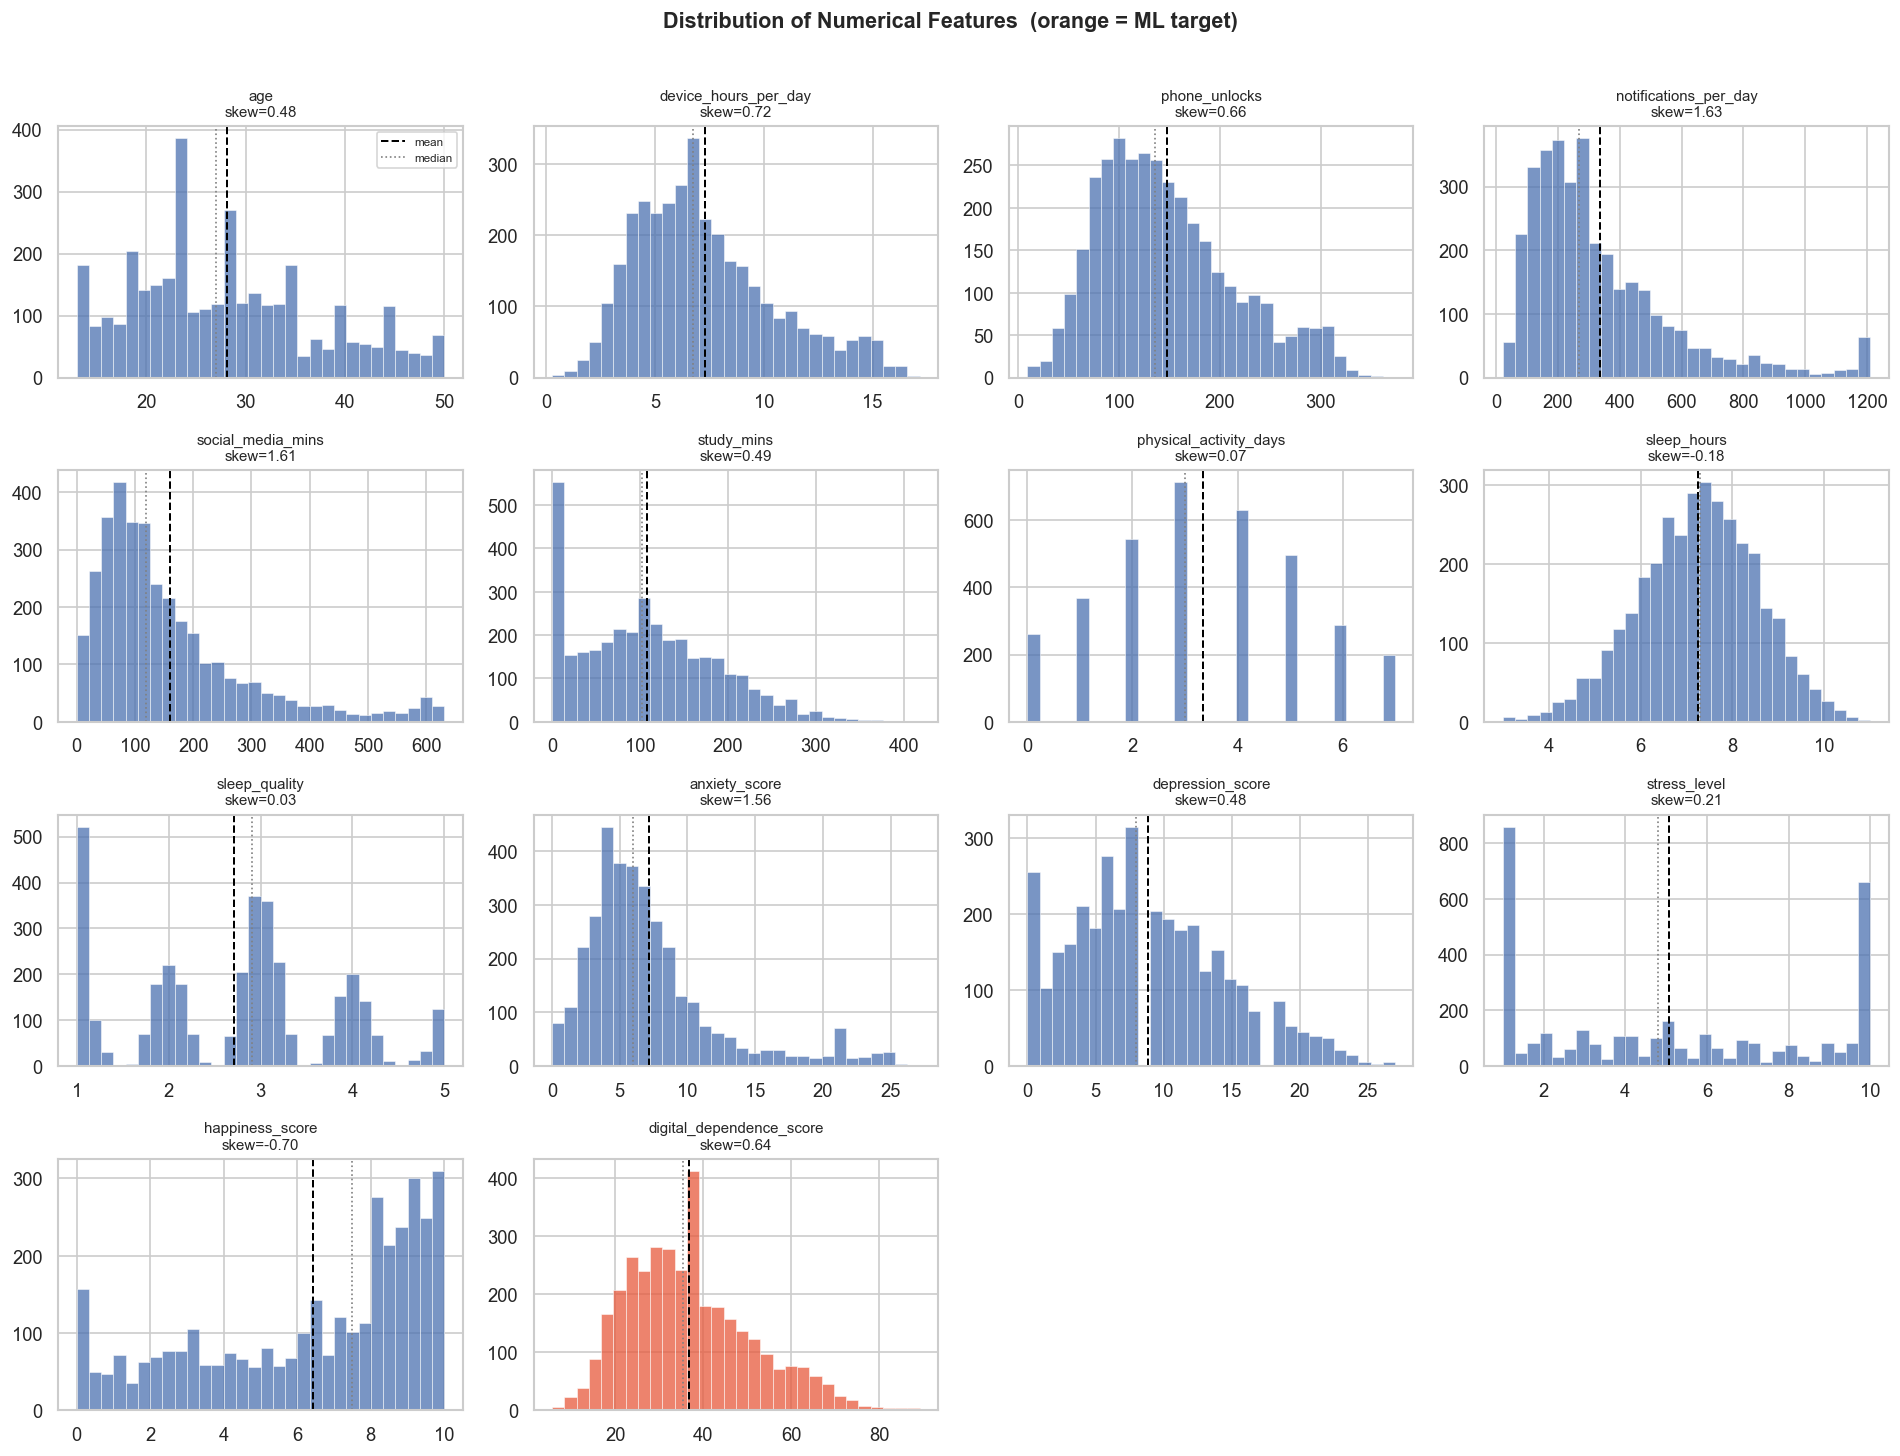

In [8]:
plot_cols = [
    'age', 'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
    'social_media_mins', 'study_mins', 'physical_activity_days', 'sleep_hours',
    'sleep_quality', 'anxiety_score', 'depression_score', 'stress_level',
    'happiness_score', 'digital_dependence_score'
]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    color = '#E8593C' if col == TARGET else '#4C72B0'
    ax.hist(df[col], bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(df[col].mean(), color='black', lw=1.2, linestyle='--', label='mean')
    ax.axvline(df[col].median(), color='gray', lw=1.0, linestyle=':', label='median')
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=9)
    ax.set_xlabel('')
    if i == 0:
        ax.legend(fontsize=7)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features  (orange = ML target)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

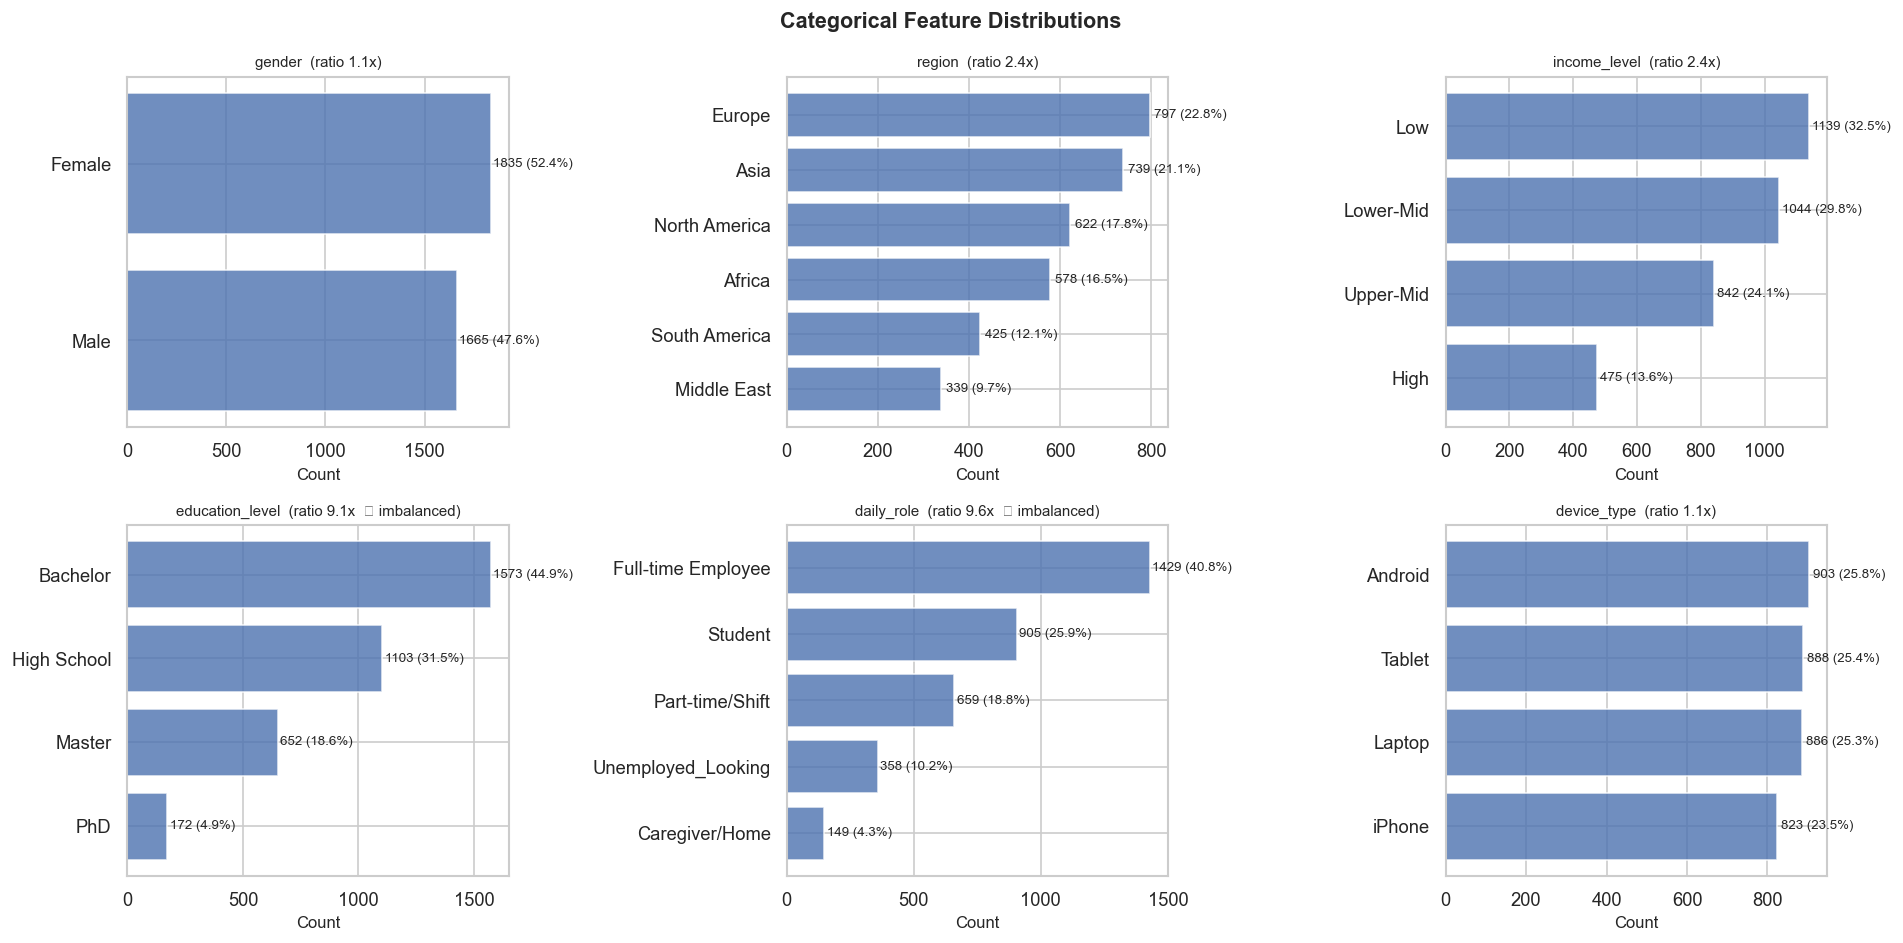

In [9]:
cat_cols = ['gender', 'region', 'income_level', 'education_level', 'daily_role', 'device_type']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = df[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color='#4C72B0', alpha=0.8)
    for j, v in enumerate(vc.values[::-1]):
        ax.text(v + 10, j, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
    ratio = vc.iloc[0] / vc.iloc[-1]
    flag = '  ⚠ imbalanced' if ratio > 5 else ''
    ax.set_title(f'{col}  (ratio {ratio:.1f}x{flag})', fontsize=9)
    ax.set_xlabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

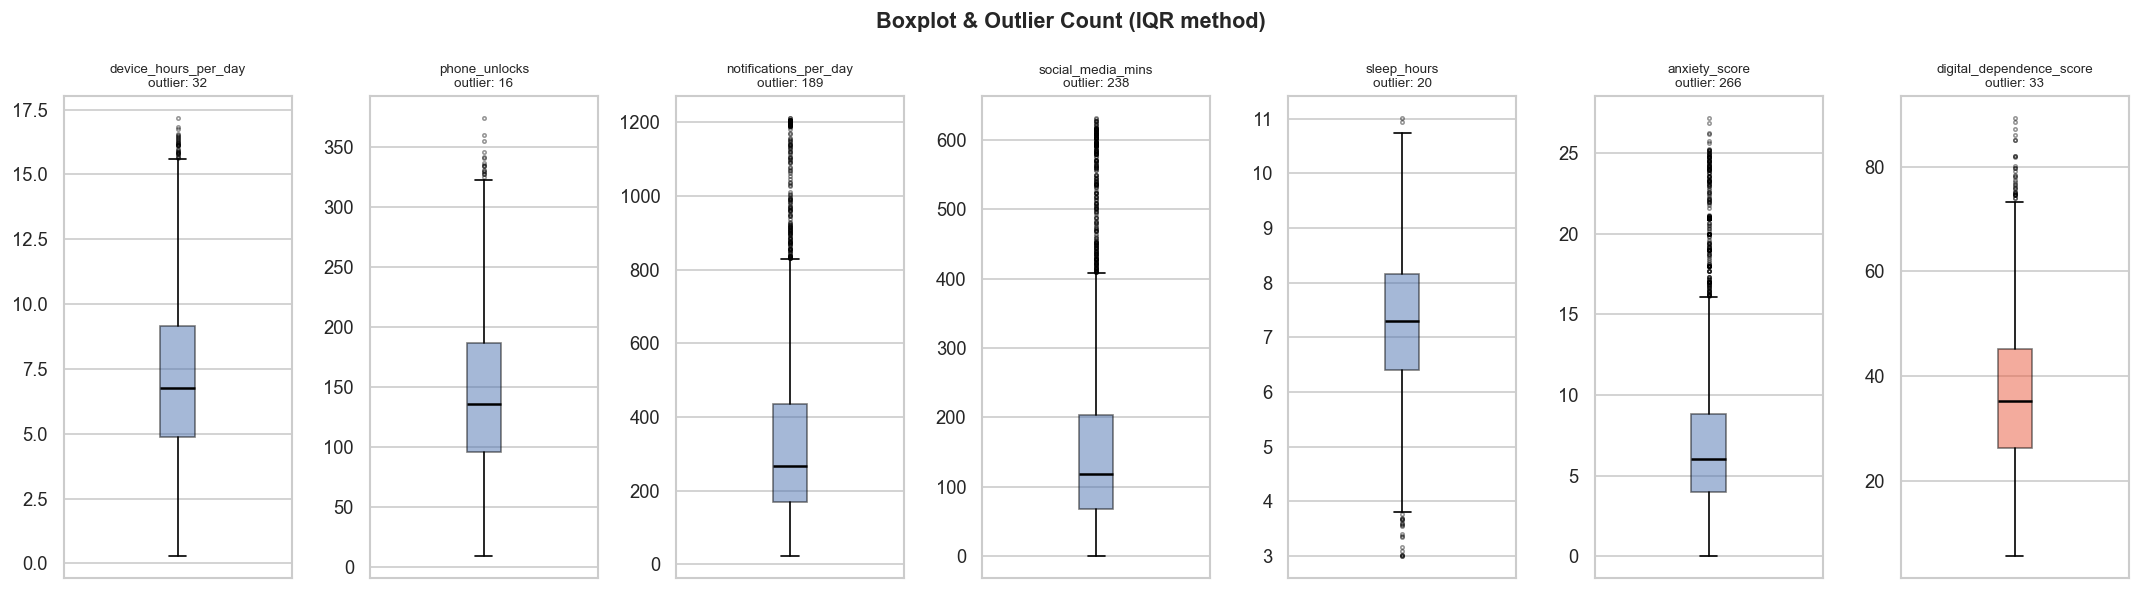

In [10]:
box_cols = [
    'device_hours_per_day', 'phone_unlocks', 'notifications_per_day',
    'social_media_mins', 'sleep_hours', 'anxiety_score', TARGET
]

fig, axes = plt.subplots(1, len(box_cols), figsize=(18, 5))

for ax, col in zip(axes, box_cols):
    color = '#E8593C' if col == TARGET else '#4C72B0'
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=1.5),
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
    Q1, Q3 = df[col].quantile([.25, .75])
    n_out = ((df[col] < Q1 - 1.5*(Q3-Q1)) | (df[col] > Q3 + 1.5*(Q3-Q1))).sum()
    ax.set_title(f'{col}\noutlier: {n_out}', fontsize=8)
    ax.set_xticks([])

plt.suptitle('Boxplot & Outlier Count (IQR method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

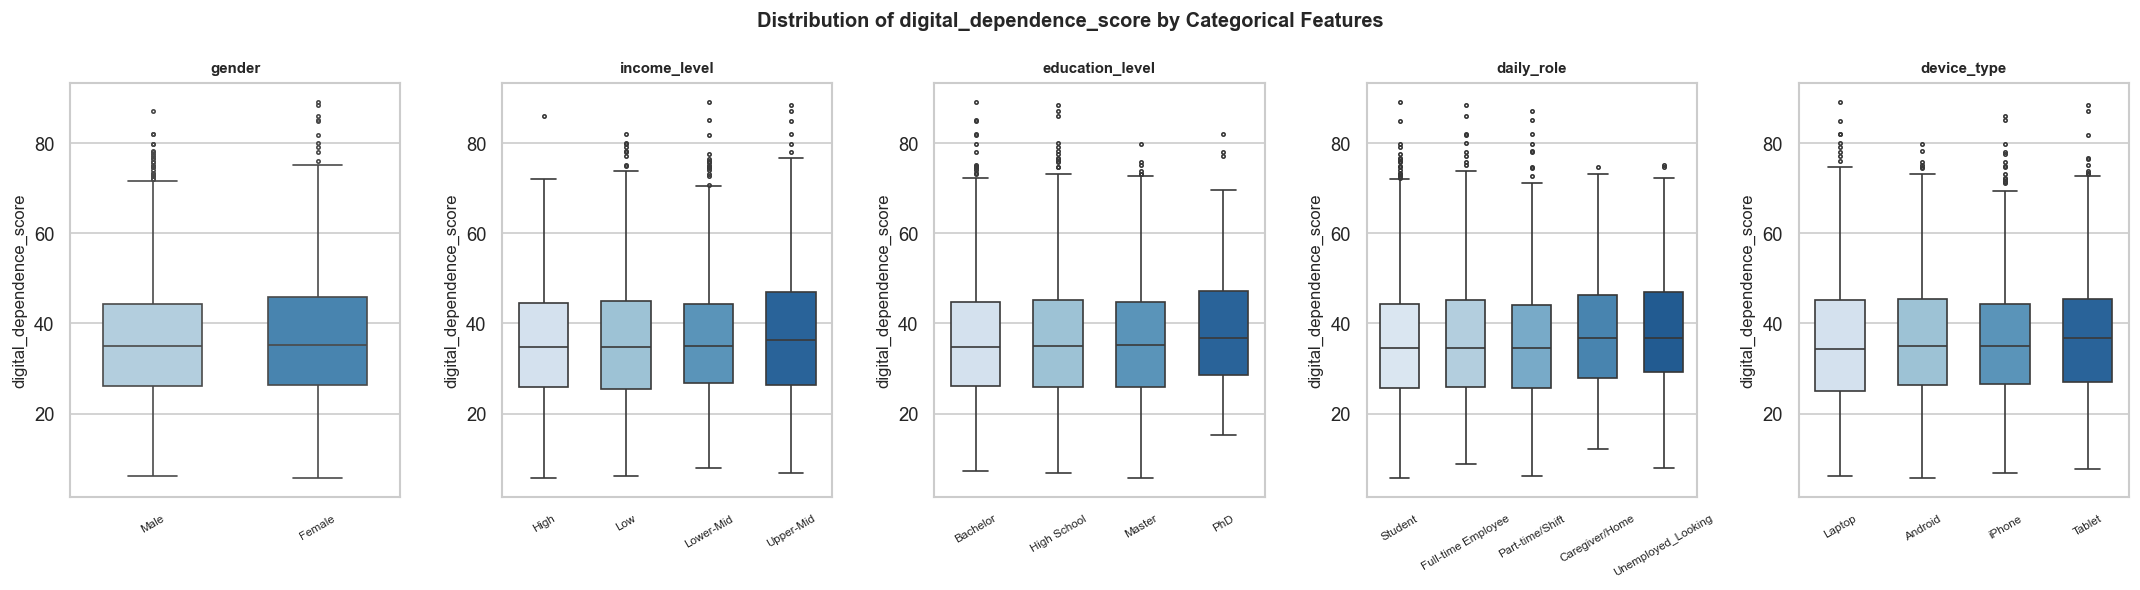

In [11]:
cat_compare = ['gender', 'income_level', 'education_level', 'daily_role', 'device_type']

fig, axes = plt.subplots(1, len(cat_compare), figsize=(18, 5))

for ax, col in zip(axes, cat_compare):
    order = df.groupby(col)[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax,
                palette='Blues', width=0.6, fliersize=2)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle(f'Distribution of {TARGET} by Categorical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()